# Install Required Libraries

In [18]:
!pip install ultralytics opencv-python numpy matplotlib tqdm

# Import Libraries


In [19]:
import cv2
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# Configuration

In [20]:
INPUT_VIDEO = "Input/input2.MP4"
OUTPUT_VIDEO = "tracked_output.mp4"
TRAJECTORY_OUTPUT_VIDEO = "tracked_with_trajectories.mp4"
SCREENSHOT_DIR = "screenshots"
METRICS_FILE = "metrics.json"

MODEL_PATH = "yolov8m.pt"

CONFIDENCE_THRESHOLD = 0.35
IOU_THRESHOLD = 0.45
SCREENSHOT_INTERVAL = 150

os.makedirs(SCREENSHOT_DIR, exist_ok=True)

# Load YOLO Model

In [21]:
print("Loading YOLO model...")
model = YOLO(MODEL_PATH)
print("Model loaded successfully.")

Loading YOLO model...
Model loaded successfully.


# Open Input Video

In [22]:
cap = cv2.VideoCapture(INPUT_VIDEO)

if not cap.isOpened():
    raise ValueError(f"Error: Could not open video file {INPUT_VIDEO}")

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video Loaded: {INPUT_VIDEO}")
print(f"Resolution: {width}x{height}")
print(f"FPS: {fps}")
print(f"Total Frames: {total_frames}")

Video Loaded: Input/input2.MP4
Resolution: 3840x2160
FPS: 29
Total Frames: 109


# Create Video Writers

In [23]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out_basic = cv2.VideoWriter(
    OUTPUT_VIDEO,
    fourcc,
    fps,
    (width, height)
)

out_trajectory = cv2.VideoWriter(
    TRAJECTORY_OUTPUT_VIDEO,
    fourcc,
    fps,
    (width, height)
)

# Initialize Tracking Variables


In [24]:
track_history = {}
unique_ids = set()

frame_count = 0
total_processing_time = 0
detection_counts = []

print("Tracking variables initialized.")

Tracking variables initialized.


# Process Video Frame by Frame

In [25]:
print("Processing video...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    start_time = time.time()

    results = model.track(
        frame,
        persist=True,
        conf=CONFIDENCE_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=False
    )

    annotated_basic = frame.copy()
    annotated_trajectory = frame.copy()

    current_detections = 0

    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.cpu().numpy().astype(int)
        classes = results[0].boxes.cls.cpu().numpy().astype(int)
        confidences = results[0].boxes.conf.cpu().numpy()

        current_detections = len(track_ids)

        for box, track_id, cls, conf in zip(boxes, track_ids, classes, confidences):
            x1, y1, x2, y2 = map(int, box)

            unique_ids.add(track_id)

            label = f"ID {track_id} | {model.names[cls]} | {conf:.2f}"

            cv2.rectangle(annotated_basic, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                annotated_basic,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            cv2.rectangle(annotated_trajectory, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(
                annotated_trajectory,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                2
            )

            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)

            if track_id not in track_history:
                track_history[track_id] = []

            track_history[track_id].append((center_x, center_y))

            if len(track_history[track_id]) > 30:
                track_history[track_id].pop(0)

            points = track_history[track_id]

            for i in range(1, len(points)):
                cv2.line(
                    annotated_trajectory,
                    points[i - 1],
                    points[i],
                    (0, 255, 255),
                    2
                )

    cv2.putText(
        annotated_basic,
        f"Frame: {frame_count}",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    cv2.putText(
        annotated_basic,
        f"Objects: {current_detections}",
        (20, 65),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    cv2.putText(
        annotated_trajectory,
        f"Frame: {frame_count}",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    cv2.putText(
        annotated_trajectory,
        f"Objects: {current_detections}",
        (20, 65),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    if frame_count % SCREENSHOT_INTERVAL == 0:
        screenshot_path = os.path.join(SCREENSHOT_DIR, f"frame_{frame_count}.jpg")
        cv2.imwrite(screenshot_path, annotated_trajectory)

    out_basic.write(annotated_basic)
    out_trajectory.write(annotated_trajectory)

    processing_time = time.time() - start_time
    total_processing_time += processing_time
    detection_counts.append(current_detections)

    frame_count += 1

print("Video processing completed.")

Processing video...
Video processing completed.


# Release Resources

In [26]:
cap.release()
out_basic.release()
out_trajectory.release()

print("Resources released successfully.")

Resources released successfully.


# Calculate Metrics

In [27]:

avg_processing_time = total_processing_time / frame_count if frame_count > 0 else 0
effective_fps = 1 / avg_processing_time if avg_processing_time > 0 else 0
avg_detections = np.mean(detection_counts) if len(detection_counts) > 0 else 0

metrics = {
    "total_frames_processed": frame_count,
    "total_unique_objects_tracked": len(unique_ids),
    "average_detections_per_frame": float(avg_detections),
    "average_processing_time_per_frame_sec": float(avg_processing_time),
    "effective_processing_fps": float(effective_fps),
    "output_video_basic": OUTPUT_VIDEO,
    "output_video_with_trajectories": TRAJECTORY_OUTPUT_VIDEO,
    "screenshots_folder": SCREENSHOT_DIR
}

with open(METRICS_FILE, "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved to metrics.json")
print(json.dumps(metrics, indent=4))

Metrics saved to metrics.json
{
    "total_frames_processed": 109,
    "total_unique_objects_tracked": 14,
    "average_detections_per_frame": 5.522935779816514,
    "average_processing_time_per_frame_sec": 0.3289279959617405,
    "effective_processing_fps": 3.040179043064233,
    "output_video_basic": "tracked_output.mp4",
    "output_video_with_trajectories": "tracked_with_trajectories.mp4",
    "screenshots_folder": "screenshots"
}


# Display Sample Screenshot

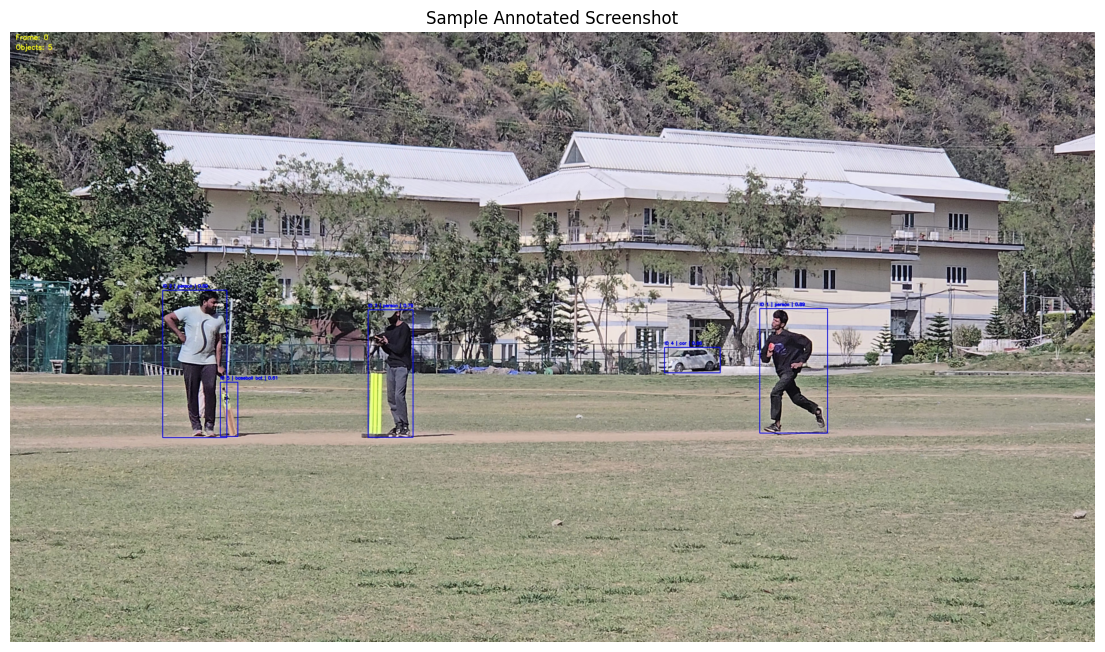

In [28]:
sample_files = sorted(os.listdir(SCREENSHOT_DIR))

if len(sample_files) > 0:
    sample_path = os.path.join(SCREENSHOT_DIR, sample_files[0])
    img = cv2.imread(sample_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Sample Annotated Screenshot")
    plt.show()
else:
    print("No screenshots found.")

# Final Output Message

In [29]:
print("Done!")
print(f"Tracked video saved as: {OUTPUT_VIDEO}")
print(f"Trajectory video saved as: {TRAJECTORY_OUTPUT_VIDEO}")
print(f"Screenshots saved in folder: {SCREENSHOT_DIR}")
print(f"Metrics saved as: {METRICS_FILE}")

Done!
Tracked video saved as: tracked_output.mp4
Trajectory video saved as: tracked_with_trajectories.mp4
Screenshots saved in folder: screenshots
Metrics saved as: metrics.json
